# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**AlexNet Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating an AlexNet model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries (calculations, data manipulation, visualization)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import deep learning libraries - tensorflow
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical

# Import metrics libraries
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

2025-03-14 11:17:22.444075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-14 11:17:22.460146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741951042.476601  292622 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741951042.480372  292622 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 11:17:22.496824: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Data Loading & Preprocessing

## Load the data

In [2]:
# Load the data
data_path = "../data/"
train_images = np.load(data_path + "train_images.npy")
train_labels = np.load(data_path + "train_labels.npy")
test_images = np.load(data_path + "test_images.npy")
test_labels = np.load(data_path + "test_labels.npy")
val_images = np.load(data_path + "val_images.npy")
val_labels = np.load(data_path + "val_labels.npy")

print("Original shapes:")
print("Train - images:", train_images.shape, " labels:", train_labels.shape)
print("Val   - images:", val_images.shape, " labels:", val_labels.shape)
print("Test  - images:", test_images.shape, " labels:", test_labels.shape)

Original shapes:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)


## Preprocess the data

In [3]:
# Preprocess data for ResNet
def preprocess_data(images, labels):
    # Reshape to include channel dimension (grayscale = 1 channel)
    images = images.reshape(images.shape[0], 28, 28, 1)
    
    # Normalize pixel values
    images = images.astype('float32') / 255.0
    
    # Convert labels to one-hot encoding
    labels = to_categorical(labels, 2)
    
    return images, labels

# Apply preprocessing to all datasets
train_images, train_labels = preprocess_data(train_images, train_labels)
val_images, val_labels = preprocess_data(val_images, val_labels)
test_images, test_labels = preprocess_data(test_images, test_labels)

print("\nAfter preprocessing:")
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Val images shape:", val_images.shape)
print("Val labels shape:", val_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Model Architecture

### Build the Model

In [4]:
def build_alexnet(input_shape=(28, 28, 1), num_classes=2, dropout_rate=0.5):
    """
    Build an AlexNet model adapted for small input size (28x28)
    """
    inputs = layers.Input(shape=input_shape)
    
    # First convolutional block
    x = layers.Conv2D(96, kernel_size=3, strides=1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    
    # Second convolutional block
    x = layers.Conv2D(256, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    
    # Third convolutional block
    x = layers.Conv2D(384, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Fourth convolutional block
    x = layers.Conv2D(384, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Fifth convolutional block
    x = layers.Conv2D(256, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    
    # Flatten and fully connected layers
    x = layers.Flatten()(x)
    x = layers.Dense(4096)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate, name="dropout1")(x)
    
    x = layers.Dense(4096)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate, name="dropout2")(x)  # Named for the dropout scheduler
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

### Create & Compile Model

In [5]:
# Create the AlexNet model
alexnet = build_alexnet(dropout_rate=0.5)

# Model architecture summary
alexnet.summary()

# Compile the model
alexnet.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

I0000 00:00:1741951044.239197  292622 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │             

 Total params: 29,589,058 (112.87 MB)

 Trainable params: 29,569,922 (112.80 MB)

 Non-trainable params: 19,136 (74.75 KB)

# Callback Definition

In [6]:
# Define callbacks
checkpoint_callback = callbacks.ModelCheckpoint(
    '../models/alexnet_best_model.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

early_stop_callback = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5
)

# List of all callbacks
all_callbacks = [
    checkpoint_callback,
    early_stop_callback,
    reduce_lr_callback
]

## Dropout Rate Scheduler Callback

In [7]:
class DropoutRateScheduler(callbacks.Callback):
    """Custom callback to adjust dropout rate during training"""
    
    def __init__(self, dropout_start=0.5, dropout_end=0.3, epochs=50):
        super().__init__()
        self.dropout_start = dropout_start
        self.dropout_end = dropout_end
        self.epochs = epochs
    
    def on_epoch_begin(self, epoch, logs=None):
        # Linear decay of dropout rate
        decay_rate = (self.dropout_start - self.dropout_end) / self.epochs
        new_dropout = self.dropout_start - decay_rate * epoch
        new_rate = max(new_dropout, self.dropout_end)
        
        # Set the dropout rate for both dropout layers
        self.model.get_layer('dropout1').rate = new_rate
        self.model.get_layer('dropout2').rate = new_rate
        print(f"Epoch {epoch+1}: dropout rate set to {new_rate:.4f}")

# Add to callbacks list
dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=50)
all_callbacks.append(dropout_scheduler)

# Model Training and Evaluation

## Train the Model

In [8]:
# Train the model
history = alexnet.fit(
    train_images,
    train_labels,
    batch_size=32,
    epochs=50,
    validation_data=(val_images, val_labels),
    callbacks=all_callbacks
)

Epoch 1: dropout rate set to 0.5000
Epoch 1/50


I0000 00:00:1741951049.024868  292676 service.cc:148] XLA service 0x736cac002410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741951049.025004  292676 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-03-14 11:17:29.127126: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741951049.729947  292676 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-14 11:17:30.356241: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,96,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,28,28]{3,2,1,0}, f32[96,1,3,3]{3,2,1,0}, f32[96]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cud

  3/148 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - AUC: 0.7375 - accuracy: 0.6736 - loss: 1.1382  

I0000 00:00:1741951056.784761  292676 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - AUC: 0.9398 - accuracy: 0.8908 - loss: 0.5939

2025-03-14 11:17:44.136183: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-14 11:17:44.207517: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,384,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,256,7,7]{3,2,1,0}, f32[384,256,3,3]{3,2,1,0}, f32[384]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivatio

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - AUC: 0.9400 - accuracy: 0.8910 - loss: 0.5922

2025-03-14 11:17:50.570898: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,96,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,1,28,28]{3,2,1,0}, f32[96,1,3,3]{3,2,1,0}, f32[96]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-14 11:17:50.603880: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 114ms/step - AUC: 0.9402 - accuracy: 0.8912 - loss: 0.5905 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 8.2248 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4960
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.9798 - accuracy: 0.9384 - loss: 0.2049 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 5.5499 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4920
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.9884 - accuracy: 0.9537 - loss: 0.1354 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 10.5094 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4880
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - AUC: 0.9822 - accuracy: 0.9398 - loss: 0.1839 - val_AUC: 0.9868 - val_accuracy: 0.9580 - val_loss: 0.1420 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4840
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.9916 - accuracy: 0.9601 - loss: 0.1133 - val_AUC: 0.8082 - val

## Evaluate the Model

In [9]:
# Evaluate the model on test data
test_loss, test_accuracy, test_auc = alexnet.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test AUC: {test_auc:.4f}")

15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.9149 - accuracy: 0.8713 - loss: 0.7673

2025-03-14 11:21:11.687886: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,96,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,1,28,28]{3,2,1,0}, f32[96,1,3,3]{3,2,1,0}, f32[96]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-14 11:21:11.691804: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - AUC: 0.9182 - accuracy: 0.8752 - loss: 0.7412
Test accuracy: 0.8846
Test loss: 0.6681
Test AUC: 0.9272


# Results

## Visualize Training History

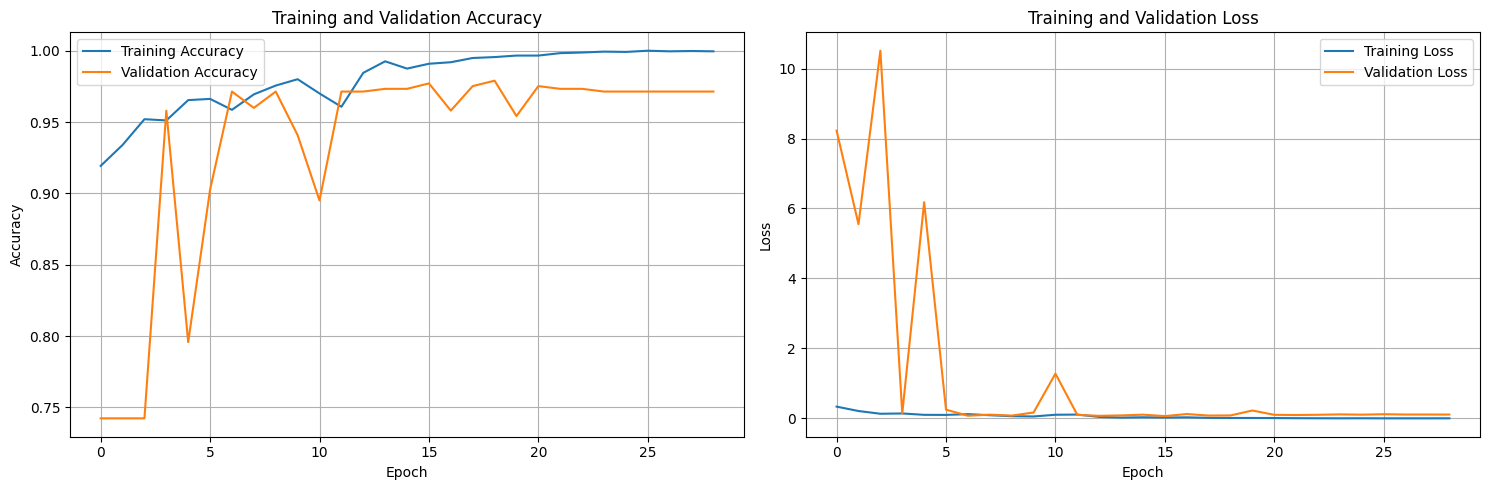

In [10]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training and Validation Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training and Validation Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


## Classification Metrics and ROC Curve

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


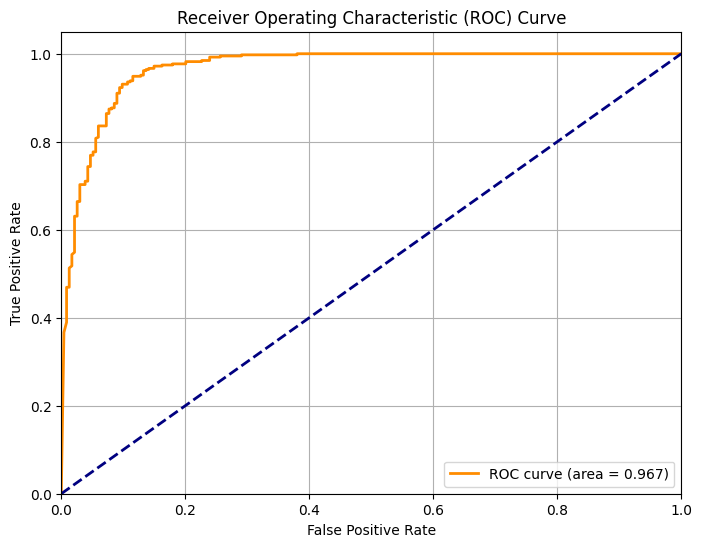

ROC AUC Score: 0.9669


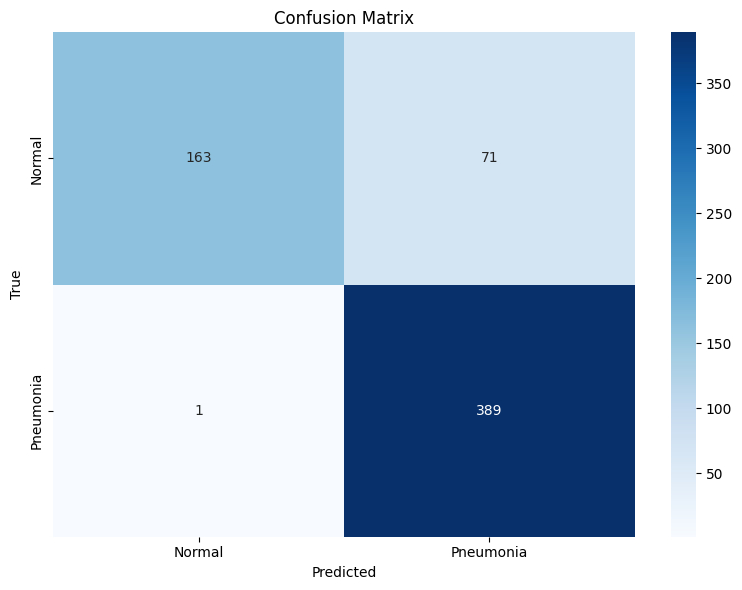

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.70      0.82       234
   Pneumonia       0.85      1.00      0.92       390

    accuracy                           0.88       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.88      0.88       624



In [11]:
# Make predictions on test data
predictions = alexnet.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels[:, 1], predictions[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print AUC score
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion matrix and classification report (existing code)
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

## Save the Model

In [13]:
# Save the model in the newer .keras format
model_path = "../models/"
model_name = "alexnet_pneumonia_model.keras"
alexnet.save(model_path + model_name)
print("Model saved successfully at:", model_path + model_name)

Model saved successfully at: ../models/alexnet_pneumonia_model.keras
